# Dr.Copper — Phase 5: Backtesting

In [1]:
import pandas as pd

import dr_copper as dc
from pathlib import Path
import backtrader as bt
from openbb import obb

import warnings

warnings.filterwarnings("ignore")

FIGURES = Path("../outputs/figures")
REPORTS = Path("../reports")
DATA = Path("../data")
TICKER = "HG=F"

## 1 — Load previous Phases outputs

In [2]:
raw = pd.read_parquet(DATA / "raw" / "raw_test.parquet")
signals = pd.read_parquet(DATA / "processed" / "copper_signal.parquet")

In [3]:
start_date = raw.index[0]
end_date = raw.index[-1]

## 2 — Data preparation for Backtrader

In [4]:
prices = obb.derivatives.futures.historical(  # type: ignore
    symbol=TICKER, start_date=start_date, end_date=end_date
).to_df()

In [5]:
bt_frame = dc.build_backtest_frame(signal=signals, prices=prices)

## 3 — Run the backtests

Every strategy will be run using the grid of values for the target_percent parameter. This parameter specifies the percentage of the invested money we want to pay for the trade. With a high value, more than 1 failure can bankrupt our portfolio, so we don't want to make it more than about 1/3 of the portfolio.

In [6]:
opt_results_signal = dc.run_backtest_opt(
    frame=bt_frame,
    strategy=dc.SignalStrategy,
    initial_cash=100_000,
    commission=2.5,
    margin=10000,
    mult=25000,
    commtype=bt.CommInfoBase.COMM_FIXED,
    slippage=0.0015,
    target_percent=[0.1, 0.15, 0.2, 0.25, 0.3, 0.35],
    printlog=False,
)

In [7]:
opt_results_signal

,target_percent,return,sharpe,dd
0,0.10,-0.58,-0.25,24.66
1,0.15,4.80,0.38,47.10
2,0.20,5.37,0.30,61.09
3,0.25,1.21,0.05,65.43
4,0.30,-31.25,-0.50,96.18
5,0.35,-45.15,-0.55,104.40


As we can see, the results of the strategy based on the signal are very poor. Only two values (0.15, 0.2) give us at least something.

In [8]:
opt_results_sma = dc.run_backtest_opt(
    frame=bt_frame,
    strategy=dc.SMAStrategy,
    initial_cash=100_000,
    commission=2.5,
    margin=10000,
    mult=25000,
    commtype=bt.CommInfoBase.COMM_FIXED,
    slippage=0.0015,
    target_percent=[0.1, 0.15, 0.2, 0.25, 0.3, 0.35],
    printlog=False,
)

In [9]:
opt_results_sma

,target_percent,return,sharpe,dd
0,0.10,-2.74,-0.41,35.26
1,0.15,6.39,0.67,39.72
2,0.20,4.02,0.25,56.98
3,0.25,1.30,0.08,59.97
4,0.30,9.92,0.49,73.99
5,0.35,7.92,0.38,77.94


A simple MA cross strategy gives mid results for almost the entire parameter range except 0.1 and 0.25.

In [10]:
opt_results_signal_sma = dc.run_backtest_opt(
    frame=bt_frame,
    strategy=dc.SignalSMAStrategy,
    initial_cash=100_000,
    commission=2.5,
    margin=10000,
    mult=25000,
    commtype=bt.CommInfoBase.COMM_FIXED,
    slippage=0.0015,
    target_percent=[0.1, 0.15, 0.2, 0.25, 0.3, 0.35],
    printlog=False,
)

In [11]:
opt_results_signal_sma

,target_percent,return,sharpe,dd
0,0.10,15.39,1.49,25.85
1,0.15,13.05,1.34,48.90
2,0.20,24.21,1.52,59.20
3,0.25,31.07,1.60,70.93
4,0.30,38.23,1.55,86.85
5,0.35,42.96,1.62,94.94


When we combine the strategies, we mean that the signal allows us to make a trade only when the MAs relative position allows. That strategy outperforms simple ones over the entire range of the parameter. Also, we can take the value 0.25 as final, considering better returns and Sharpe, but not yet too large max drawdowns.

## 4 — The backtest with the optimal parameter

In [12]:
results_signal_sma = dc.run_backtest(
    frame=bt_frame,
    strategy=dc.SignalSMAStrategy,
    initial_cash=100_000,
    commission=2.5,
    margin=10000,
    mult=25000,
    commtype=bt.CommInfoBase.COMM_FIXED,
    slippage=0.0015,
    target_percent=0.25,
    printlog=False,
)

Starting equity: 100,000.00
Ending equity:   242,202.56


<IPython.core.display.Javascript object>

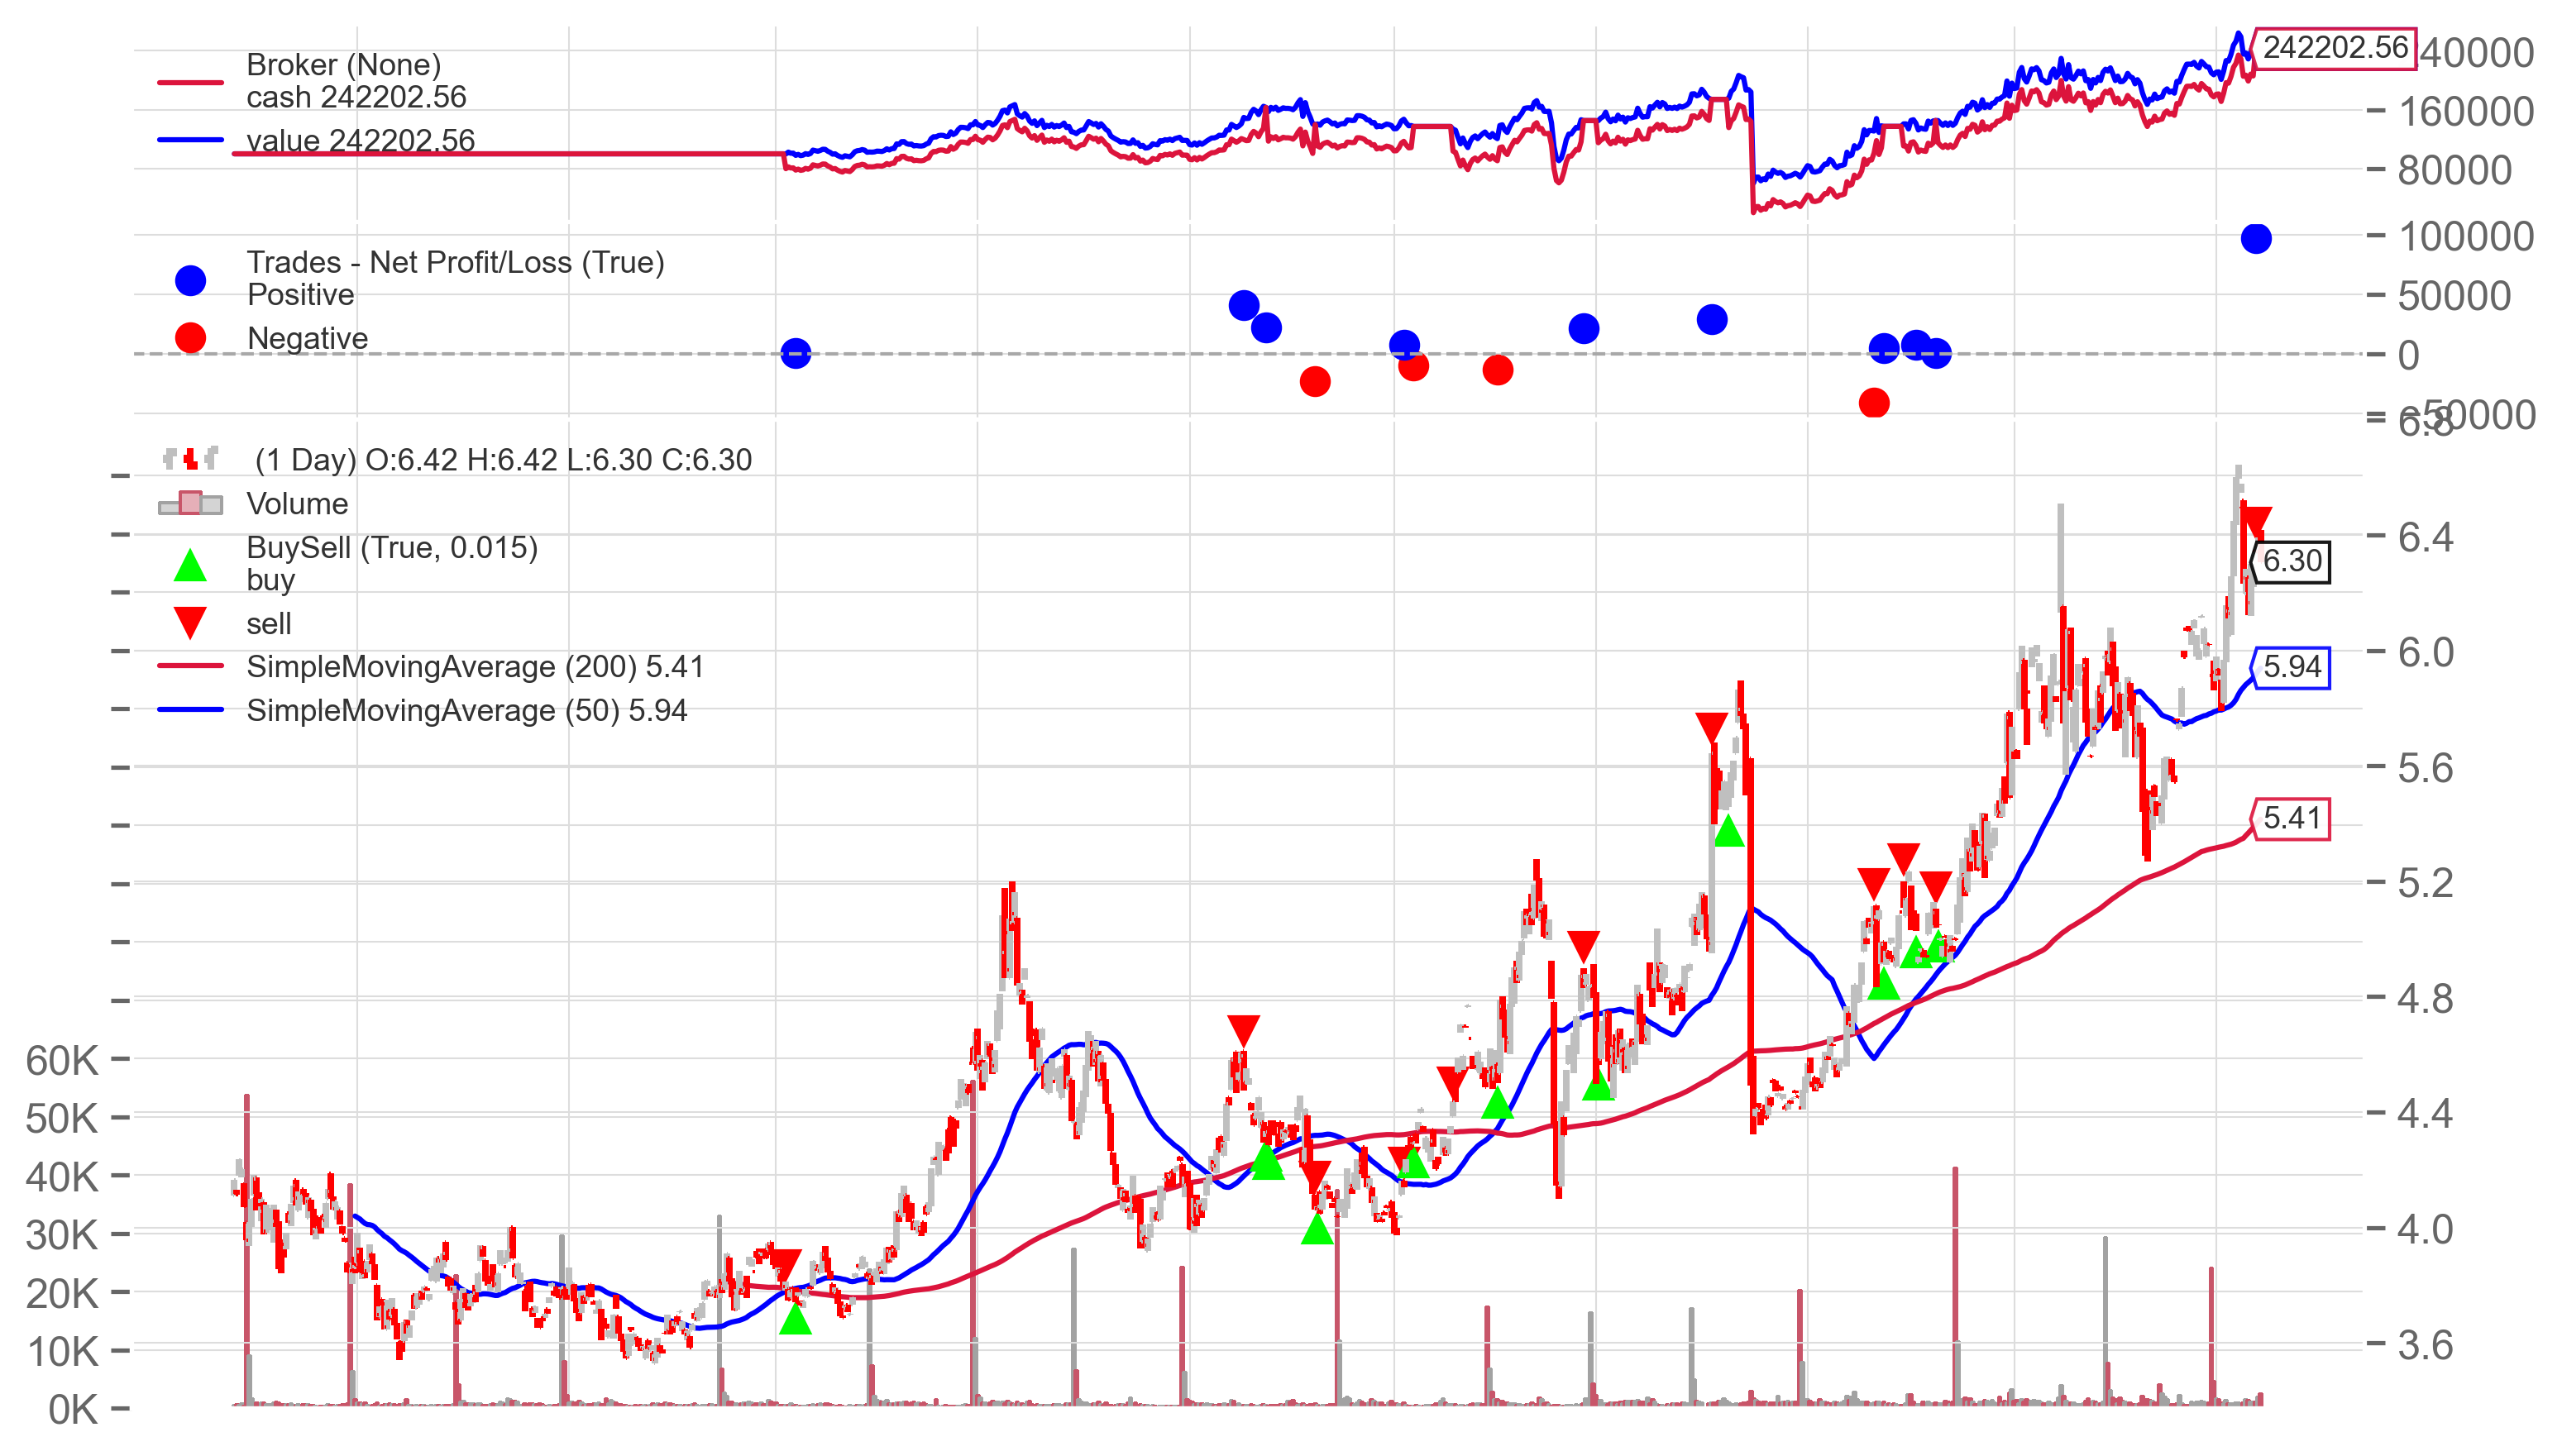

In [13]:
results_signal_sma["fig"]

## 5 — Benchmark: buy-and-hold HG=F

In [14]:
benchmark_returns = dc.benchmark_returns_from_prices(prices)
benchmark_returns = benchmark_returns.reindex(
    results_signal_sma["returns"].index
).fillna(0)

## 6 — Key metrics + full quantstats tearsheet

In [15]:
dc.print_key_metrics(results_signal_sma["returns"], benchmark_returns)

KEY METRICS — strategy
Sharpe            : 0.841
Sortino           : 1.094
Calmar            : 0.438
CAGR              : 31.07%
Max Drawdown      : -70.93%
Volatility (ann.) : 65.79%
Win rate          : 53.11%
Profit factor     : 1.234
------------------------------------------------------------
KEY METRICS — benchmark (buy & hold HG=F)
------------------------------------------------------------
Sharpe            : 0.592
Calmar            : 0.535
CAGR              : 13.52%
Max Drawdown      : -25.27%


### Full quantstats tearsheet

In [16]:
dc.generate_html_tearsheet(
    results_signal_sma["returns"],
    benchmark=benchmark_returns,
    output_path=REPORTS / "Phase_5_tearsheet.html",
    title="Dr.Copper Phase 5 Tearsheet: HG=F Directional Signal vs Buy-and-Hold",
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tearsheet written to ..\reports\Phase_5_tearsheet.html
